In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


In [2]:
states = ['/s/', '/p/', '/iː/', '/tʃ/']


In [3]:
observations = ['Energy', 'Pitch', 'Duration']


In [4]:
initial_prob = {
    '/s/': 1.0,
    '/p/': 0.0,
    '/iː/': 0.0,
    '/tʃ/': 0.0
}


In [5]:
transition_prob = pd.DataFrame([
    [0.1, 0.8, 0.1, 0.0],
    [0.0, 0.1, 0.8, 0.1],
    [0.0, 0.0, 0.2, 0.8],
    [0.2, 0.0, 0.0, 0.8]
],
columns=states, index=states)

transition_prob


,/s/,/p/,/iː/,/tʃ/
/s/,0.1,0.8,0.1,0.0
/p/,0.0,0.1,0.8,0.1
/iː/,0.0,0.0,0.2,0.8
/tʃ/,0.2,0.0,0.0,0.8


In [6]:
emission_prob = pd.DataFrame([
    [0.7, 0.2, 0.1],   # /s/
    [0.5, 0.3, 0.2],   # /p/
    [0.3, 0.5, 0.2],   # /iː/
    [0.4, 0.4, 0.2]    # /tʃ/
], columns=observations, index=states)

emission_prob


,Energy,Pitch,Duration
/s/,0.7,0.2,0.1
/p/,0.5,0.3,0.2
/iː/,0.3,0.5,0.2
/tʃ/,0.4,0.4,0.2


In [7]:
def display_hmm():
    print("=== INITIAL PROBABILITIES ===")
    display(pd.DataFrame(initial_prob, index=[0]))
    print("\n=== TRANSITION PROBABILITY MATRIX ===")
    display(transition_prob)
    print("\n=== EMISSION PROBABILITY MATRIX ===")
    display(emission_prob)

display_hmm()


=== INITIAL PROBABILITIES ===


,/s/,/p/,/iː/,/tʃ/
0,1.0,0.0,0.0,0.0



=== TRANSITION PROBABILITY MATRIX ===


,/s/,/p/,/iː/,/tʃ/
/s/,0.1,0.8,0.1,0.0
/p/,0.0,0.1,0.8,0.1
/iː/,0.0,0.0,0.2,0.8
/tʃ/,0.2,0.0,0.0,0.8



=== EMISSION PROBABILITY MATRIX ===


,Energy,Pitch,Duration
/s/,0.7,0.2,0.1
/p/,0.5,0.3,0.2
/iː/,0.3,0.5,0.2
/tʃ/,0.4,0.4,0.2


In [8]:
def choose_state(prob_vector):
    return np.random.choice(states, p=prob_vector)


In [9]:
def generate_phoneme_sequence(length=4):
    sequence = []
    current_state = '/s/'  # given

    sequence.append(current_state)

    for _ in range(length - 1):
        next_state = choose_state(transition_prob.loc[current_state].values)
        sequence.append(next_state)
        current_state = next_state

    return sequence


In [10]:
def generate_observations(phoneme_sequence):
    obs_sequence = []
    for ph in phoneme_sequence:
        obs = np.random.choice(observations, p=emission_prob.loc[ph].values)
        obs_sequence.append(obs)
    return obs_sequence


In [11]:
phonemes = generate_phoneme_sequence()
observs = generate_observations(phonemes)

print("Generated phoneme sequence:", phonemes)
print("Generated acoustic observations:", observs)


Generated phoneme sequence: ['/s/', np.str_('/p/'), np.str_('/iː/'), np.str_('/tʃ/')]
Generated acoustic observations: [np.str_('Energy'), np.str_('Pitch'), np.str_('Duration'), np.str_('Duration')]


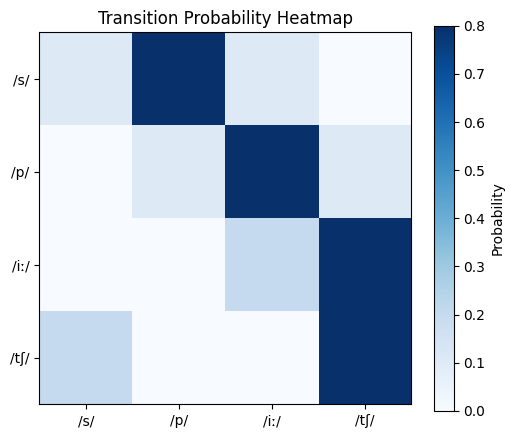

In [12]:
plt.figure(figsize=(6,5))
plt.title("Transition Probability Heatmap")
plt.imshow(transition_prob, cmap='Blues')
plt.xticks(range(len(states)), states)
plt.yticks(range(len(states)), states)
plt.colorbar(label='Probability')
plt.show()


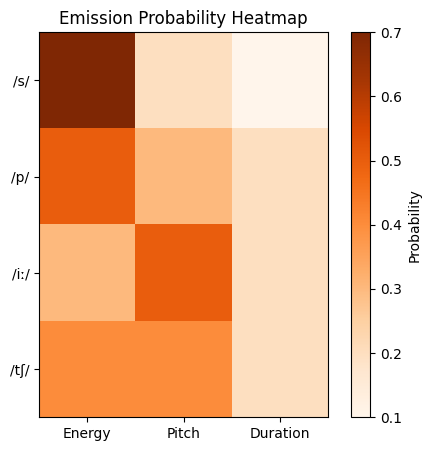

In [13]:
plt.figure(figsize=(6,5))
plt.title("Emission Probability Heatmap")
plt.imshow(emission_prob, cmap='Oranges')
plt.xticks(range(len(observations)), observations)
plt.yticks(range(len(states)), states)
plt.colorbar(label='Probability')
plt.show()


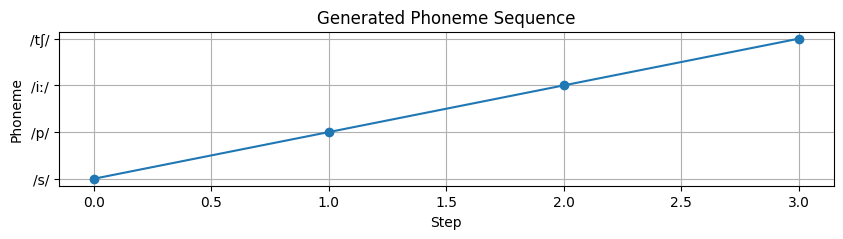

In [14]:
plt.figure(figsize=(10,2))
plt.plot(phonemes, marker='o')
plt.title("Generated Phoneme Sequence")
plt.xlabel("Step")
plt.ylabel("Phoneme")
plt.grid(True)
plt.show()
